# TT-16 — Decision Tree Regressor
## Định giá cước chuyến xe — bảng giá dạng LUẬT cho tổng đài


In [1]:
%pip install numpy pandas scikit-learn matplotlib pyarrow requests tqdm

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached pyarrow-25.0.1-cp310-cp310-win_amd64.whl (27.8 MB)
  Using cached requests-2.34.2-py3-none-any.whl (73 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl (508 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
     ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/41.3 MB 1.3 MB/s eta 0:00:33
     --------------------------------------- 0.1/41.3 MB 919.0 kB/s eta 0:00:45
     --------------------------------------- 0.1/41.3 MB 819.2 kB/s eta 0:00:51
     --------------------------------------- 0.2/41.3 MB 984.6 kB/s eta 0:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)


## Bước 1 — Tải dữ liệu & lấy mẫu 200.000 dòng



In [9]:
import os

DATA_DIR = r"C:\QNhu_Tuat\QuynhNhu_Lab_ML\Hoc may\02- Hoi quy\TT-16"
FILE_NAME = "yellow_tripdata_2024-01.parquet"   
FILE_PATH = os.path.join(DATA_DIR, FILE_NAME)

SAMPLE_SIZE = 200_000

df_full = pd.read_parquet(FILE_PATH)
print("Tổng số dòng gốc:", len(df_full))

df = df_full.sample(n=min(SAMPLE_SIZE, len(df_full)), random_state=RANDOM_STATE).reset_index(drop=True)
del df_full  
print("Số dòng sau khi lấy mẫu:", len(df))
df.head()

Tổng số dòng gốc: 2964624
Số dòng sau khi lấy mẫu: 200000


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.0,17.14,2.0,N,132,233,1,70.0,0.0,0.5,8.27,6.94,1.0,90.96,2.5,1.75
1,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.0,2.49,1.0,N,163,75,1,13.5,1.0,0.5,4.00,0.00,1.0,22.50,2.5,0.00
2,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.0,1.84,1.0,N,127,20,2,10.0,1.0,0.5,0.00,0.00,1.0,12.50,0.0,0.00
3,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.0,3.60,1.0,N,186,263,1,23.3,3.5,0.5,5.65,0.00,1.0,33.95,2.5,0.00
4,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.0,0.04,1.0,N,238,238,2,3.7,1.0,0.5,0.00,0.00,1.0,6.20,0.0,0.00


## Bước 2 — Làm sạch dữ liệu 



In [10]:
n_before = len(df)
log_loai_bo = {}

# (a) fare_amount <= 0 -> chuyến huỷ / hoàn tiền
mask_fare = df["fare_amount"] <= 0
log_loai_bo["fare_amount <= 0"] = int(mask_fare.sum())

# (b) trip_distance vô lý
mask_dist = (df["trip_distance"] <= 0) | (df["trip_distance"] > 100)
log_loai_bo["trip_distance <= 0 hoac > 100 miles"] = int(mask_dist.sum())

# (c) passenger_count == 0 (hoặc thiếu)
mask_pax = df["passenger_count"].fillna(0) == 0
log_loai_bo["passenger_count == 0"] = int(mask_pax.sum())

mask_loai = mask_fare | mask_dist | mask_pax
df_clean = df.loc[~mask_loai].copy()

print("--- SỐ DÒNG BỊ LOẠI THEO TỪNG ĐIỀU KIỆN ---")
for k, v in log_loai_bo.items():
    print(f"  {k:40s}: {v:>8,} dòng")
print(f"  {'TỔNG LOẠI (không trùng lặp)':40s}: {n_before - len(df_clean):>8,} dòng")
print(f"\nSố dòng trước khi làm sạch : {n_before:,}")
print(f"Số dòng sau khi làm sạch   : {len(df_clean):,}  ({len(df_clean)/n_before:.1%} giữ lại)")

df = df_clean
del df_clean


--- SỐ DÒNG BỊ LOẠI THEO TỪNG ĐIỀU KIỆN ---
  fare_amount <= 0                        :    2,679 dòng
  trip_distance <= 0 hoac > 100 miles     :    3,981 dòng
  passenger_count == 0                    :   11,665 dòng
  TỔNG LOẠI (không trùng lặp)             :   16,367 dòng

Số dòng trước khi làm sạch : 200,000
Số dòng sau khi làm sạch   : 183,633  (91.8% giữ lại)


In [11]:

COT_RO_RI = ["tip_amount", "tolls_amount", "total_amount"]
print("Các cột KHÔNG được dùng làm đặc trưng (rò rỉ):", COT_RO_RI)


Các cột KHÔNG được dùng làm đặc trưng (rò rỉ): ['tip_amount', 'tolls_amount', 'total_amount']


## Bước 3 — Tạo đặc trưng thời gian

In [12]:
df["gio_don"] = df["tpep_pickup_datetime"].dt.hour
df["thu_trong_tuan"] = df["tpep_pickup_datetime"].dt.dayofweek  

def la_gio_cao_diem(row):
    if row["thu_trong_tuan"] >= 5:  
        return 0
    return int((7 <= row["gio_don"] <= 9) or (16 <= row["gio_don"] <= 19))

df["gio_cao_diem"] = df.apply(la_gio_cao_diem, axis=1)

df[["tpep_pickup_datetime", "gio_don", "thu_trong_tuan", "gio_cao_diem"]].head()


,tpep_pickup_datetime,gio_don,thu_trong_tuan,gio_cao_diem
0,2024-01-20 13:31:30,13,5,0
1,2024-01-18 21:52:46,21,3,0
2,2024-01-01 03:43:58,3,0,0
3,2024-01-19 22:20:12,22,4,0
4,2024-01-06 22:41:50,22,5,0


## Bước 4 — EDA: quãng đường vs cước, giá trung bình theo giờ

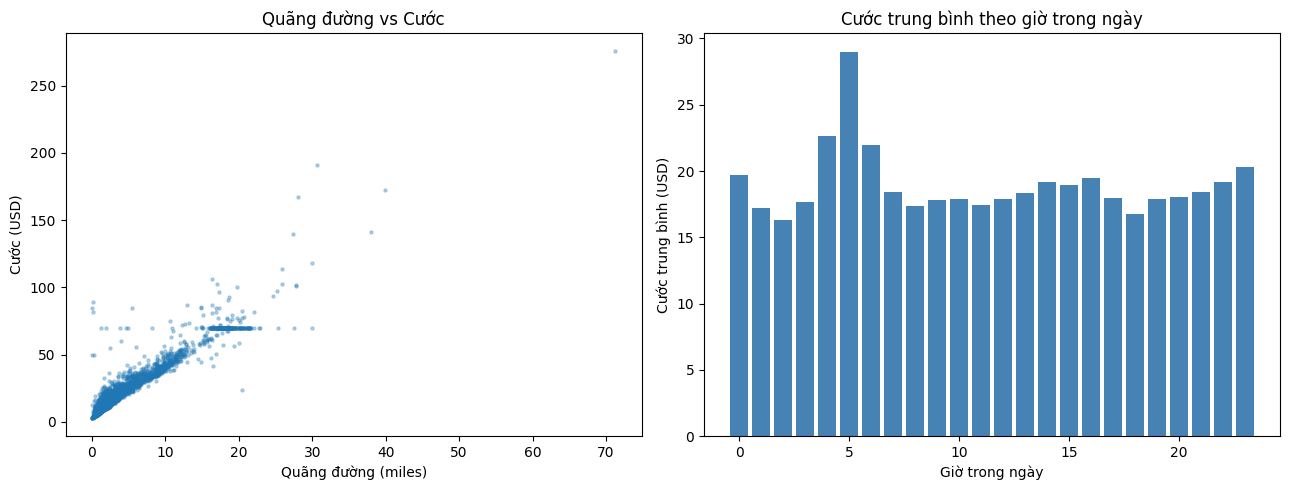

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sample_plot = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
ax[0].scatter(sample_plot["trip_distance"], sample_plot["fare_amount"], s=5, alpha=0.3)
ax[0].set_xlabel("Quãng đường (miles)")
ax[0].set_ylabel("Cước (USD)")
ax[0].set_title("Quãng đường vs Cước")

gia_theo_gio = df.groupby("gio_don")["fare_amount"].mean()
ax[1].bar(gia_theo_gio.index, gia_theo_gio.values, color="steelblue")
ax[1].set_xlabel("Giờ trong ngày")
ax[1].set_ylabel("Cước trung bình (USD)")
ax[1].set_title("Cước trung bình theo giờ trong ngày")

plt.tight_layout()
plt.show()


## Chuẩn bị dữ liệu train/test


In [14]:
FEATURES = [
    "trip_distance", "passenger_count",
    "PULocationID", "DOLocationID",
    "gio_don", "thu_trong_tuan", "gio_cao_diem",
]
TARGET = "fare_amount"

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (146906, 7)  Test: (36727, 7)


## Bước 5 — Baseline



In [ ]:
def bao_cao_metric(ten, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{ten:35s} | MAE={mae:6.2f} | MAPE={mape:6.2f}% | RMSE={rmse:6.2f}")
    return {"model": ten, "MAE": mae, "MAPE": mape, "RMSE": rmse}

ket_qua = []

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
ket_qua.append(bao_cao_metric("Baseline - DummyRegressor(mean)", y_test, dummy.predict(X_test)))

HE_SO_CHAN = 12000 / 25000  
HE_SO_GOC = 8500 / 25000 * 1.60934 

y_pred_thu_cong = HE_SO_CHAN + HE_SO_GOC * X_test["trip_distance"]
ket_qua.append(bao_cao_metric("Baseline - Cong thuc tuyen tinh thu cong", y_test, y_pred_thu_cong))


Baseline - DummyRegressor(mean)     | MAE= 11.15 | MAPE= 89.84% | RMSE= 17.36
Baseline - Cong thuc tuyen tinh thu cong | MAE= 16.15 | MAPE= 88.46% | RMSE= 22.08


## Bước 6 — Cây KHÔNG giới hạn độ sâu → chứng minh overfit


In [16]:
tree_full = DecisionTreeRegressor(random_state=RANDOM_STATE) 
tree_full.fit(X_train, y_train)

mae_train_full = mean_absolute_error(y_train, tree_full.predict(X_train))
mae_test_full = mean_absolute_error(y_test, tree_full.predict(X_test))

print(f"Số lá của cây không giới hạn độ sâu: {tree_full.get_n_leaves():,}")
print(f"Độ sâu thực tế của cây             : {tree_full.get_depth()}")
print(f"MAE train : {mae_train_full:.3f}")
print(f"MAE test  : {mae_test_full:.3f}")
print(f"\n=> Chênh lệch train/test rất lớn => cây học thuộc lòng dữ liệu train => OVERFIT rõ ràng.")


Số lá của cây không giới hạn độ sâu: 117,701
Độ sâu thực tế của cây             : 41
MAE train : 0.009
MAE test  : 2.725

=> Chênh lệch train/test rất lớn => cây học thuộc lòng dữ liệu train => OVERFIT rõ ràng.


## Bước 7 — MAE train/test theo max_depth = 1..20 → chọn điểm tối ưu

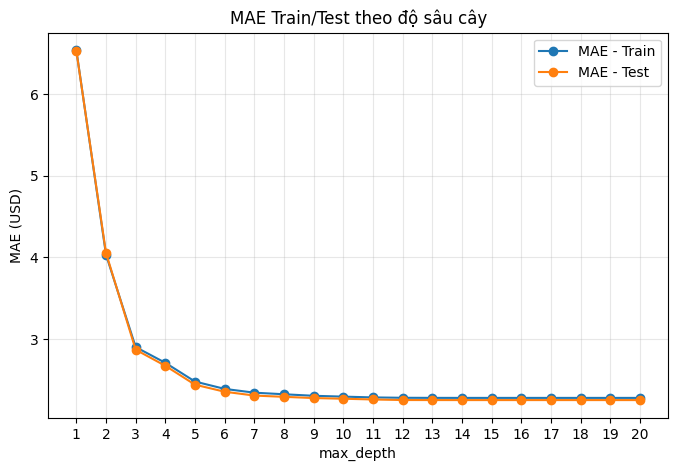

Độ sâu cho MAE test thấp nhất trong khoảng khảo sát: max_depth = 14
Lưu ý: mục tiêu là bảng tra CƯỚC cho tổng đài (yêu cầu ①), nên vẫn ưu tiên cây nông (4-5 tầng) dù không phải điểm MAE thấp tuyệt đối.


In [17]:
depths = range(1, 21)
mae_train_list, mae_test_list = [], []

for d in depths:
    t = DecisionTreeRegressor(max_depth=d, min_samples_leaf=500, random_state=RANDOM_STATE)
    t.fit(X_train, y_train)
    mae_train_list.append(mean_absolute_error(y_train, t.predict(X_train)))
    mae_test_list.append(mean_absolute_error(y_test, t.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(depths), mae_train_list, marker="o", label="MAE - Train")
plt.plot(list(depths), mae_test_list, marker="o", label="MAE - Test")
plt.xlabel("max_depth")
plt.ylabel("MAE (USD)")
plt.title("MAE Train/Test theo độ sâu cây")
plt.xticks(list(depths))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = list(depths)[int(np.argmin(mae_test_list))]
print(f"Độ sâu cho MAE test thấp nhất trong khoảng khảo sát: max_depth = {best_depth}")
print("Lưu ý: mục tiêu là bảng tra CƯỚC cho tổng đài (yêu cầu ①), nên vẫn ưu tiên cây nông (4-5 tầng) dù không phải điểm MAE thấp tuyệt đối.")


## Bước 8 — Vẽ hàm dự đoán theo quãng đường → nhìn thấy hình BẬC THANG

Cố định các đặc trưng khác theo giá trị phổ biến nhất, chỉ cho `trip_distance` chạy từ 0 đến giá trị lớn,
so sánh với dữ liệu thật để thấy rõ dạng bậc thang của cây hồi quy (khác với đường mượt của hồi quy tuyến tính).

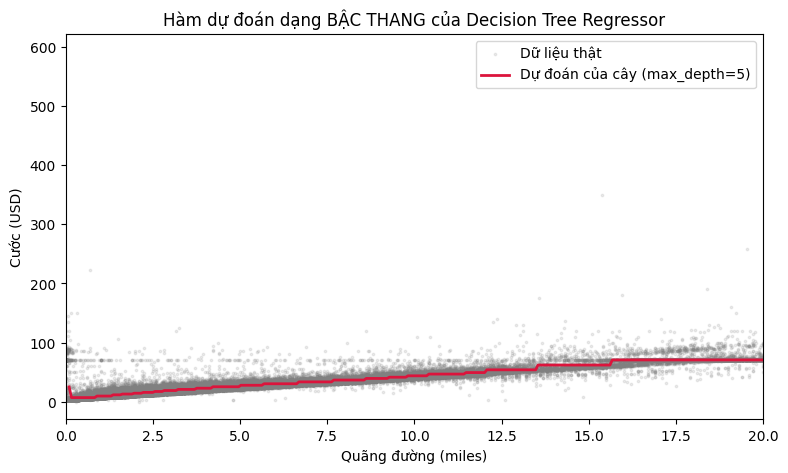

Số mức giá (số lá) mà cây max_depth=5 có thể đưa ra: 26


In [18]:
tree5_demo = DecisionTreeRegressor(max_depth=5, min_samples_leaf=500, random_state=RANDOM_STATE)
tree5_demo.fit(X_train, y_train)

gia_tri_pho_bien = {
    "passenger_count": X_train["passenger_count"].mode()[0],
    "PULocationID": X_train["PULocationID"].mode()[0],
    "DOLocationID": X_train["DOLocationID"].mode()[0],
    "gio_don": 14,
    "thu_trong_tuan": 2,
    "gio_cao_diem": 0,
}

khoang_cach_gia = np.linspace(0.1, X_train["trip_distance"].quantile(0.99), 300)
X_bac_thang = pd.DataFrame({
    "trip_distance": khoang_cach_gia,
    **{k: [v] * len(khoang_cach_gia) for k, v in gia_tri_pho_bien.items()},
})[FEATURES]

y_bac_thang = tree5_demo.predict(X_bac_thang)

plt.figure(figsize=(9, 5))
plt.scatter(df["trip_distance"], df["fare_amount"], s=3, alpha=0.15, label="Dữ liệu thật", color="gray")
plt.plot(khoang_cach_gia, y_bac_thang, color="crimson", linewidth=2, label="Dự đoán của cây (max_depth=5)")
plt.xlim(0, X_train["trip_distance"].quantile(0.99))
plt.xlabel("Quãng đường (miles)")
plt.ylabel("Cước (USD)")
plt.title("Hàm dự đoán dạng BẬC THANG của Decision Tree Regressor")
plt.legend()
plt.show()

print(f"Số mức giá (số lá) mà cây max_depth=5 có thể đưa ra: {tree5_demo.get_n_leaves()}")


## Bước 9 — Cây `max_depth=5` chính thức → `export_text` + vẽ cây



In [19]:
tree = DecisionTreeRegressor(
    max_depth=5,               
    min_samples_leaf=500,      
    criterion="squared_error",
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)

print("Số lá:", tree.get_n_leaves())
print()
print(export_text(tree, feature_names=FEATURES))


Số lá: 26

|--- trip_distance <= 7.66
|   |--- trip_distance <= 2.50
|   |   |--- trip_distance <= 1.36
|   |   |   |--- trip_distance <= 0.15
|   |   |   |   |--- value: [25.06]
|   |   |   |--- trip_distance >  0.15
|   |   |   |   |--- trip_distance <= 0.86
|   |   |   |   |   |--- value: [7.00]
|   |   |   |   |--- trip_distance >  0.86
|   |   |   |   |   |--- value: [9.60]
|   |   |--- trip_distance >  1.36
|   |   |   |--- trip_distance <= 1.90
|   |   |   |   |--- trip_distance <= 1.62
|   |   |   |   |   |--- value: [11.67]
|   |   |   |   |--- trip_distance >  1.62
|   |   |   |   |   |--- value: [12.99]
|   |   |   |--- trip_distance >  1.90
|   |   |   |   |--- trip_distance <= 2.18
|   |   |   |   |   |--- value: [14.39]
|   |   |   |   |--- trip_distance >  2.18
|   |   |   |   |   |--- value: [15.78]
|   |--- trip_distance >  2.50
|   |   |--- trip_distance <= 4.21
|   |   |   |--- trip_distance <= 3.22
|   |   |   |   |--- trip_distance <= 2.80
|   |   |   |   |   |--- 

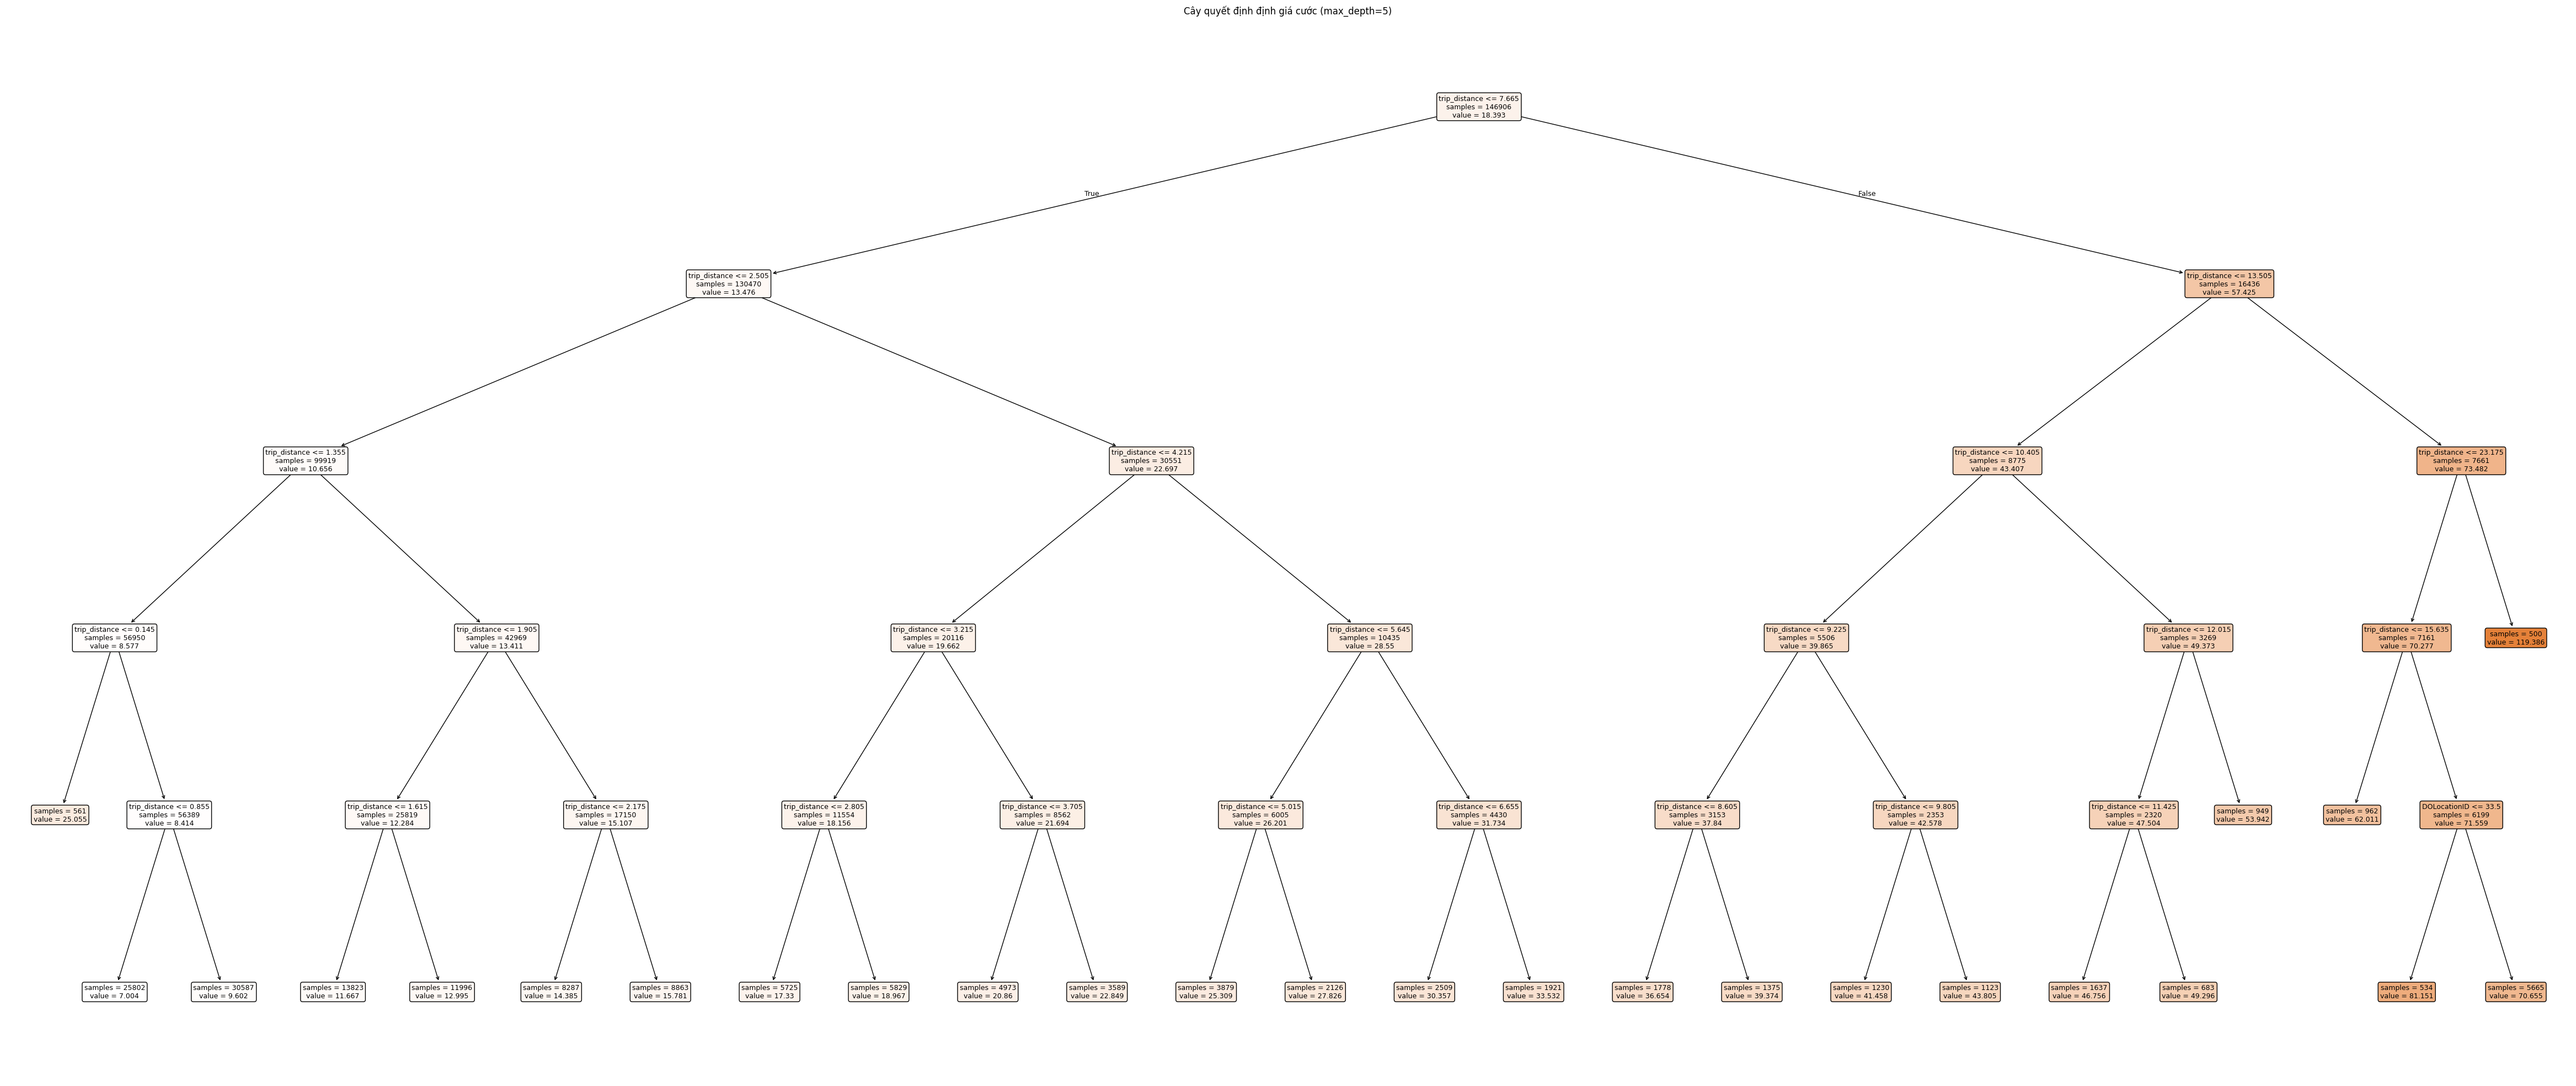

Đã lưu: cay_quyet_dinh.svg — mở bằng Chrome/Edge/trình duyệt và Ctrl+scroll để zoom, chữ sẽ luôn nét.


In [ ]:
plt.figure(figsize=(60, 25))
plot_tree(
    tree,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=5,
    impurity=False,
    proportion=False,
)
plt.title("Cây quyết định định giá cước (max_depth=5)")
plt.savefig("cay_quyet_dinh.svg", format="svg", bbox_inches="tight")  # SVG: vector, zoom không vỡ chữ
plt.show()
print("Đã lưu: cay_quyet_dinh.svg — mở bằng Chrome/Edge/trình duyệt và Ctrl+scroll để zoom, chữ sẽ luôn nét.")

In [24]:
y_pred_test = tree.predict(X_test)
ket_qua.append(bao_cao_metric("Decision Tree (max_depth=5)", y_test, y_pred_test))

for r in ket_qua:
    print(r)


Decision Tree (max_depth=5)         | MAE=  2.44 | MAPE= 22.35% | RMSE=  5.63
{'model': 'Baseline - DummyRegressor(mean)', 'MAE': 11.152337631384214, 'MAPE': 89.84253685799429, 'RMSE': np.float64(17.35561767922408)}
{'model': 'Baseline - Cong thuc tuyen tinh thu cong', 'MAE': 16.148538722914584, 'MAPE': 88.46100409829782, 'RMSE': np.float64(22.084555649717792)}
{'model': 'Decision Tree (max_depth=5)', 'MAE': 2.440615856114953, 'MAPE': 22.35241306234654, 'RMSE': np.float64(5.626314185322902)}


## Bước 10 —  Chuyển cây thành BẢNG TRA CƯỚC (CSV) cho tổng đài


In [25]:
def trich_xuat_luat(tree_model, feature_names):
    """Duyệt cây và trả về danh sách luật dạng: [(dieu_kien_text, gia_du_doan, so_mau)]"""
    tree_ = tree_model.tree_
    feat_name = [
        feature_names[i] if i != -2 else "leaf"
        for i in tree_.feature
    ]
    luat_list = []

    def duyet(node, dieu_kien):
        if tree_.feature[node] != -2:  # không phải lá
            ten_dt = feat_name[node]
            nguong = tree_.threshold[node]
            duyet(tree_.children_left[node], dieu_kien + [f"{ten_dt} <= {nguong:.2f}"])
            duyet(tree_.children_right[node], dieu_kien + [f"{ten_dt} > {nguong:.2f}"])
        else:
            gia = tree_.value[node][0][0]
            so_mau = tree_.n_node_samples[node]
            luat_list.append({
                "dieu_kien": " VA ".join(dieu_kien) if dieu_kien else "(mọi trường hợp)",
                "gia_du_doan_usd": round(float(gia), 2),
                "so_mau_lich_su": int(so_mau),
            })

    duyet(0, [])
    return luat_list

bang_tra_cuoc = pd.DataFrame(trich_xuat_luat(tree, FEATURES))
bang_tra_cuoc = bang_tra_cuoc.sort_values("gia_du_doan_usd").reset_index(drop=True)

os.makedirs("outputs", exist_ok=True)
bang_tra_cuoc.to_csv("outputs/bang_tra_cuoc.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất {len(bang_tra_cuoc)} luật (= {tree.get_n_leaves()} lá) ra outputs/bang_tra_cuoc.csv")
bang_tra_cuoc


Đã xuất 26 luật (= 26 lá) ra outputs/bang_tra_cuoc.csv


,dieu_kien,gia_du_doan_usd,so_mau_lich_su
0,trip_distance <= 7.66 VA trip_distance <= 2.50...,7.00,25802
1,trip_distance <= 7.66 VA trip_distance <= 2.50...,9.60,30587
2,trip_distance <= 7.66 VA trip_distance <= 2.50...,11.67,13823
3,trip_distance <= 7.66 VA trip_distance <= 2.50...,12.99,11996
4,trip_distance <= 7.66 VA trip_distance <= 2.50...,14.39,8287
5,trip_distance <= 7.66 VA trip_distance <= 2.50...,15.78,8863
6,trip_distance <= 7.66 VA trip_distance > 2.50 ...,17.33,5725
7,trip_distance <= 7.66 VA trip_distance > 2.50 ...,18.97,5829
8,trip_distance <= 7.66 VA trip_distance > 2.50 ...,20.86,4973
9,trip_distance <= 7.66 VA trip_distance > 2.50 ...,22.85,3589


## Bước 11 — Kiểm tra: bao nhiêu % chuyến có sai số trong ±15%?

Tỉ lệ chuyến có sai số dự đoán trong khoảng ±15%: 59.6%
Yêu cầu nghiệp vụ ③ là sai số chấp nhận ±15% -> CHƯA ĐẠT, cần xem lại độ sâu cây hoặc đặc trưng


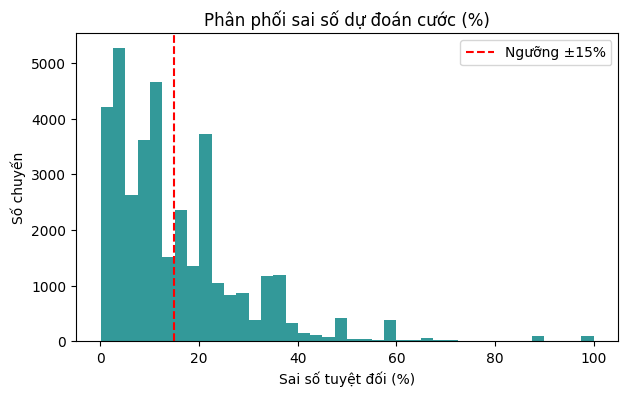

In [26]:
sai_so_phan_tram = np.abs((y_pred_test - y_test) / y_test) * 100
ty_le_dat_15pct = (sai_so_phan_tram <= 15).mean() * 100

print(f"Tỉ lệ chuyến có sai số dự đoán trong khoảng ±15%: {ty_le_dat_15pct:.1f}%")
print(f"Yêu cầu nghiệp vụ ③ là sai số chấp nhận ±15% -> ", end="")
print("ĐẠT" if ty_le_dat_15pct >= 80 else "CHƯA ĐẠT, cần xem lại độ sâu cây hoặc đặc trưng")

plt.figure(figsize=(7, 4))
plt.hist(sai_so_phan_tram.clip(0, 100), bins=40, color="teal", alpha=0.8)
plt.axvline(15, color="red", linestyle="--", label="Ngưỡng ±15%")
plt.xlabel("Sai số tuyệt đối (%)")
plt.ylabel("Số chuyến")
plt.title("Phân phối sai số dự đoán cước (%)")
plt.legend()
plt.show()


## Bước 12 — So sánh với Random Forest Regressor (TT-17) và Linear Regression

In [27]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=50,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
ket_qua.append(bao_cao_metric("Random Forest Regressor", y_test, rf.predict(X_test)))

lr = LinearRegression()
lr.fit(X_train, y_train)
ket_qua.append(bao_cao_metric("Linear Regression", y_test, lr.predict(X_test)))

bang_so_sanh = pd.DataFrame(ket_qua)
bang_so_sanh


Random Forest Regressor             | MAE=  2.02 | MAPE= 18.47% | RMSE=  4.64
Linear Regression                   | MAE=  2.64 | MAPE= 23.68% | RMSE=  5.36


,model,MAE,MAPE,RMSE
0,Baseline - DummyRegressor(mean),11.152338,89.842537,17.355618
1,Baseline - Cong thuc tuyen tinh thu cong,16.148539,88.461004,22.084556
2,Decision Tree (max_depth=5),2.440616,22.352413,5.626314
3,Random Forest Regressor,2.018496,18.470262,4.637883
4,Linear Regression,2.636228,23.684935,5.361881


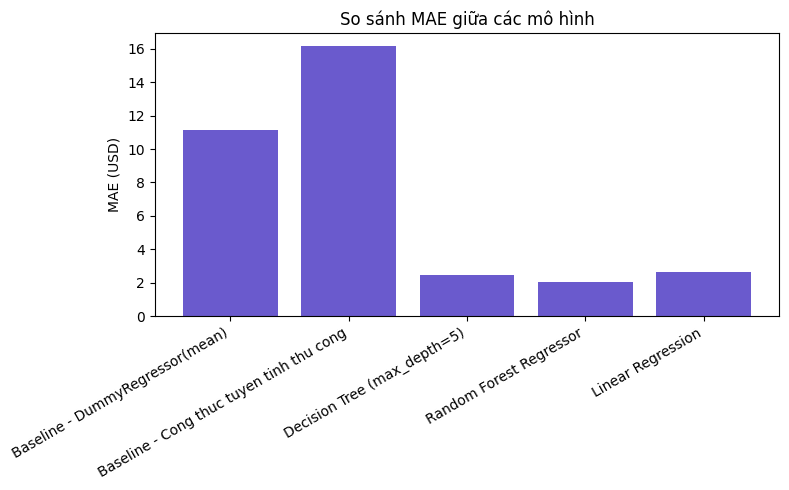

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(bang_so_sanh["model"], bang_so_sanh["MAE"], color="slateblue")
plt.ylabel("MAE (USD)")
plt.title("So sánh MAE giữa các mô hình")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("mae_theo_depth.png", dpi=150, bbox_inches="tight")
plt.show()


## VÌ SAO CÂY KHÔNG NGOẠI SUY ĐƯỢC?

Decision Tree Regressor chỉ có thể trả về giá trị trung bình của các điểm dữ liệu train đã rơi vào từng lá.
Cây không có công thức đại số (như `y = a + bx`) để "ngoại suy" ra ngoài phạm vi dữ liệu đã thấy —
nó chỉ biết so sánh ngưỡng (`trip_distance <= x?`) rồi đi theo nhánh có sẵn.

**Ví dụ cụ thể:** một chuyến đi 200 km (xa hơn bất kỳ chuyến nào trong dữ liệu train) sẽ vẫn rơi vào
nhánh "quãng đường > ngưỡng lớn nhất" và nhận đúng mức giá trung bình của lá xa nhất mà cây từng thấy —
dù thực tế chuyến 200 km phải đắt hơn nhiều. Cell dưới đây minh hoạ trực tiếp điều này.

In [29]:
chuyen_test = pd.DataFrame([{
    "trip_distance": 200,  
    "passenger_count": 1,
    "PULocationID": int(X_train["PULocationID"].mode()[0]),
    "DOLocationID": int(X_train["DOLocationID"].mode()[0]),
    "gio_don": 14,
    "thu_trong_tuan": 2,
    "gio_cao_diem": 0,
}])[FEATURES]

gia_du_doan_200km = tree.predict(chuyen_test)[0]
quang_duong_xa_nhat_trong_train = X_train["trip_distance"].max()

print(f"Quãng đường xa nhất từng thấy trong tập train: {quang_duong_xa_nhat_trong_train:.1f} miles")
print(f"Giá cây dự đoán cho chuyến 200 miles          : {gia_du_doan_200km:.2f} USD")
print("=> Cây KHÔNG thể ước lượng giá tăng thêm theo quãng đường vượt ngoài dữ liệu đã học,")
print("   nó chỉ lặp lại đúng mức giá của lá xa nhất mà nó từng gặp trong lúc huấn luyện.")


Quãng đường xa nhất từng thấy trong tập train: 99.0 miles
Giá cây dự đoán cho chuyến 200 miles          : 119.39 USD
=> Cây KHÔNG thể ước lượng giá tăng thêm theo quãng đường vượt ngoài dữ liệu đã học,
   nó chỉ lặp lại đúng mức giá của lá xa nhất mà nó từng gặp trong lúc huấn luyện.
